# Exploratory Data Analysis

This notebook explores the Wine Quality dataset after data cleaning.
The goal is to understand the distributions and relationships in the data
before building the classification models.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../data/wine_clean.csv")

data.head()


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,type,is_good,is_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,0,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,0,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,0,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,0,1
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red,0,1


In [3]:
data.shape

(5320, 15)

In [4]:
data.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type', 'is_good', 'is_red'],
      dtype='str')

## Dataset Overview

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5320 entries, 0 to 5319
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         5320 non-null   float64
 1   volatile_acidity      5320 non-null   float64
 2   citric_acid           5320 non-null   float64
 3   residual_sugar        5320 non-null   float64
 4   chlorides             5320 non-null   float64
 5   free_sulfur_dioxide   5320 non-null   float64
 6   total_sulfur_dioxide  5320 non-null   float64
 7   density               5320 non-null   float64
 8   pH                    5320 non-null   float64
 9   sulphates             5320 non-null   float64
 10  alcohol               5320 non-null   float64
 11  quality               5320 non-null   int64  
 12  type                  5320 non-null   str    
 13  is_good               5320 non-null   int64  
 14  is_red                5320 non-null   int64  
dtypes: float64(11), int64(3), str(1)

## Summary Statistics

In [6]:
data.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,is_good,is_red
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677,0.189662,0.255451
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772,0.392070,0.436155
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000,0.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000,0.000000,0.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000,0.000000,0.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000,0.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000,1.000000


## Feature Distributions

In [7]:
features = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide", "density",
    "pH", "sulphates", "alcohol"
]

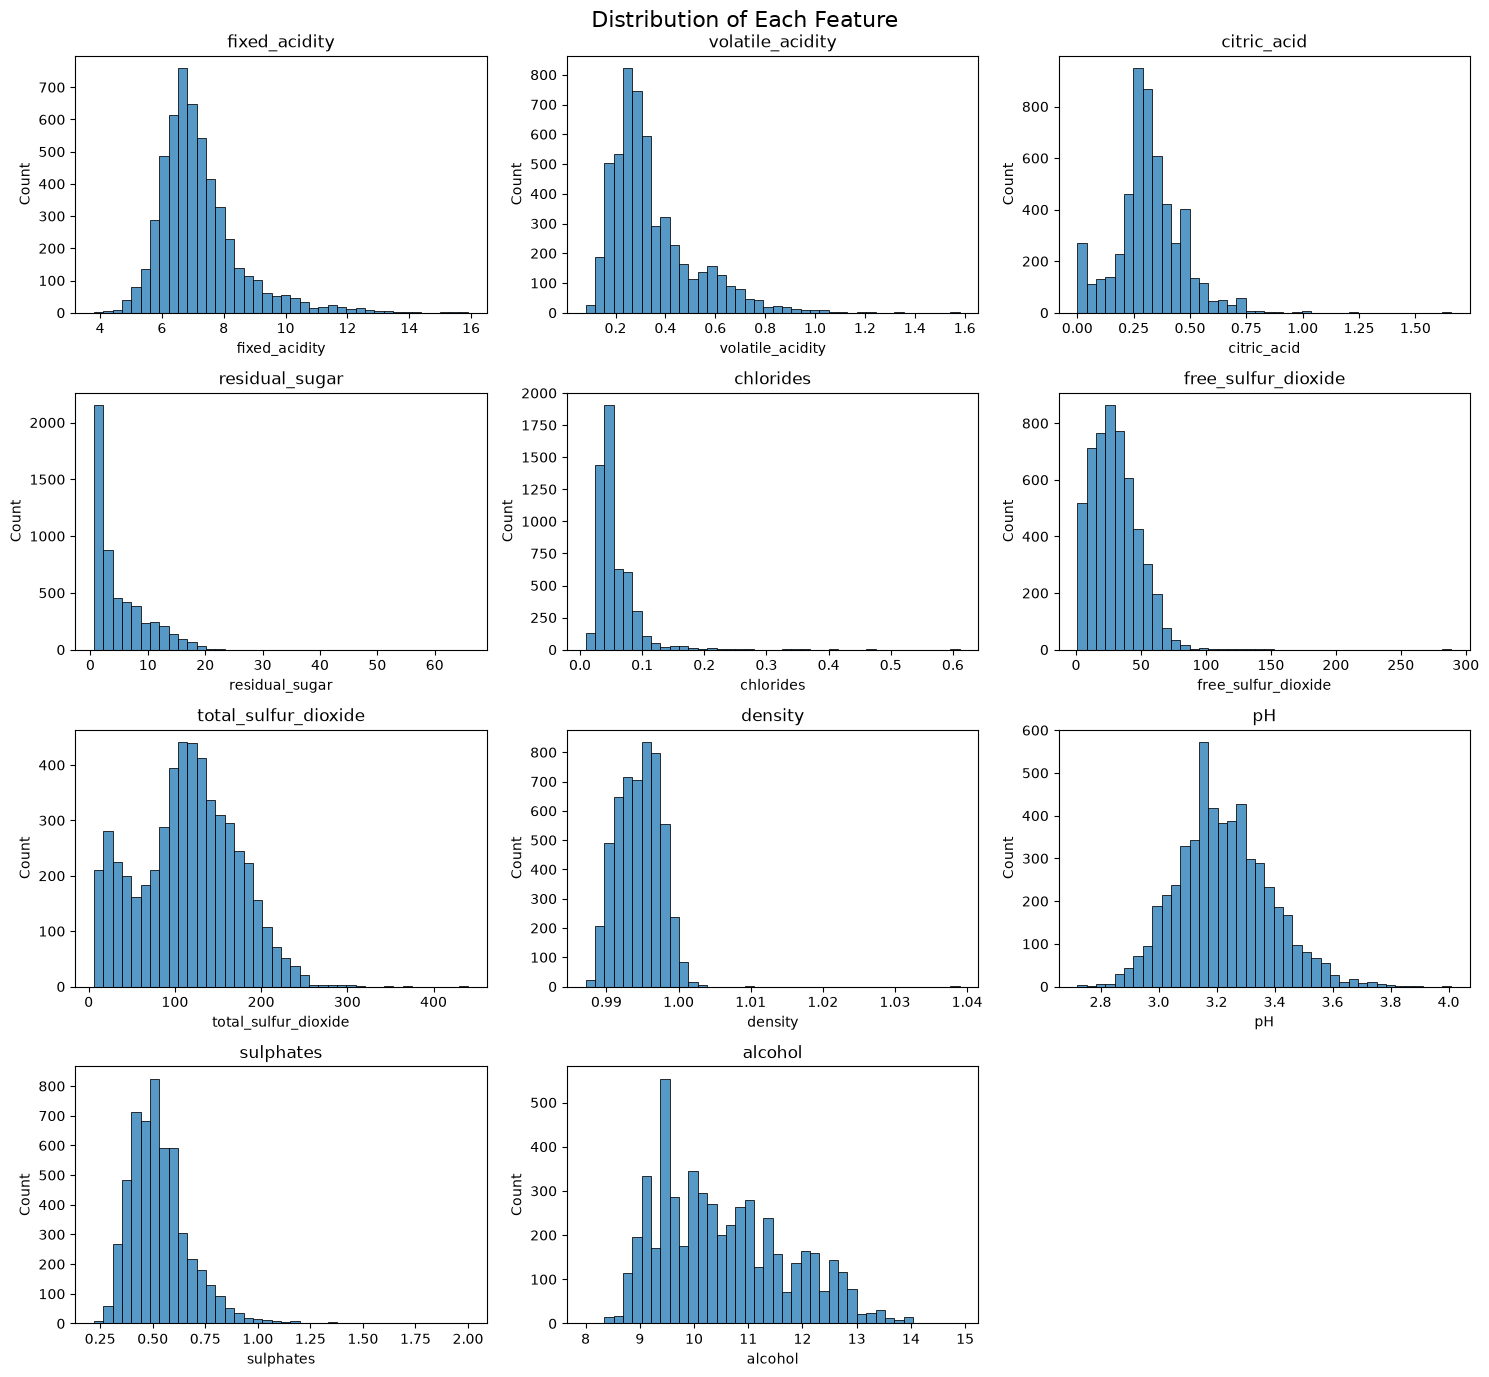

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(data=data, x=feature, bins=40, ax=axes[i])
    axes[i].set_title(feature)

axes[-1].set_visible(False)

plt.suptitle("Distribution of Each Feature", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
data[features].skew().sort_values(ascending=False)

chlorides               5.338237
sulphates               1.809454
residual_sugar          1.706550
fixed_acidity           1.650417
volatile_acidity        1.504557
free_sulfur_dioxide     1.362719
density                 0.666326
alcohol                 0.545696
citric_acid             0.484309
pH                      0.389969
total_sulfur_dioxide    0.063614
dtype: float64

### Observation

Most features are right-skewed, with a long tail of high values. Chlorides is by far the most skewed (skewness 5.34), followed by sulphates (1.81), residual sugar (1.71), fixed acidity (1.65), volatile acidity (1.50), and free sulfur dioxide (1.36). Total sulfur dioxide is close to symmetric (0.06), but its histogram has two peaks because red wines have much lower values than white wines. pH, citric acid, alcohol, and density are only mildly skewed. The skewed features could affect models that are sensitive to scale, such as logistic regression, so feature scaling (or a log transform) should be considered in the modeling step. Tree-based models are not affected by skew.

 ## Distribution of Wine Quality

In [10]:
data["is_good"].value_counts()

is_good
0    4311
1    1009
Name: count, dtype: int64

In [11]:
data["is_good"].value_counts(normalize=True) * 100

is_good
0    81.033835
1    18.966165
Name: proportion, dtype: float64

## Distribution of Wine Quality Classes

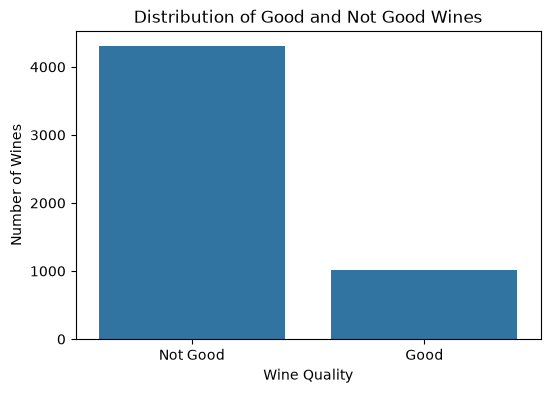

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(data=data, x="is_good")

plt.title("Distribution of Good and Not Good Wines")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")
plt.xticks([0, 1], ["Not Good", "Good"])

plt.show()

### Observation

The dataset contains more wines classified as not good than good. This shows that the target variable is imbalanced, with the not good class representing most of the observations.

## Distribution of Wine Quality Scores

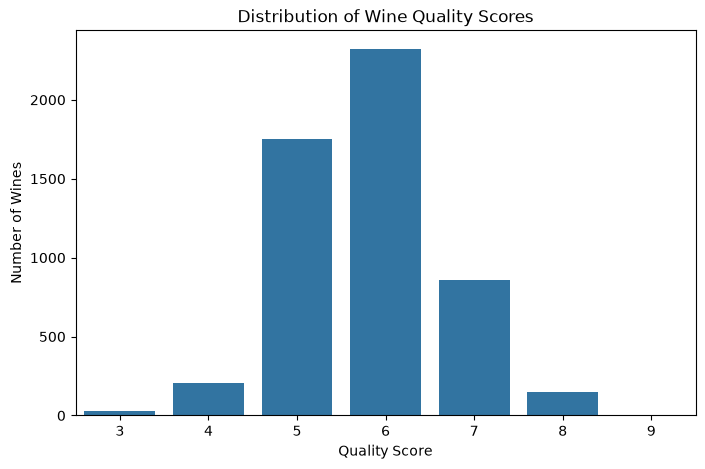

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(data=data, x="quality")

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")

plt.show()

### Observation

Most wines have quality scores of 5 or 6 and very few wines have quality scores of 3, 8, or 9.
 The distribution is concentrated around the middle quality scores.


## Average Feature Values by Quality Class

In [14]:
data.groupby("is_good")[["alcohol", "volatile_acidity", "sulphates", "pH"]].mean()

,alcohol,volatile_acidity,sulphates,pH
is_good,,,,
0,10.309587,0.355879,0.530694,3.220914
1,11.573175,0.293930,0.544737,3.240684


## Alcohol Content by Wine Quality Class

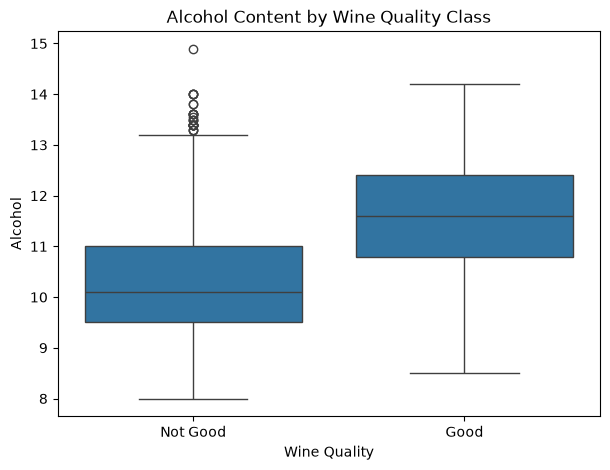

In [15]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=data, x="is_good", y="alcohol")

plt.title("Alcohol Content by Wine Quality Class")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")
plt.xticks([0, 1], ["Not Good", "Good"])

plt.show()

### Observation

Good wines generally have higher alcohol levels than Not Good wines. The median alcohol level is higher for the Good group, although there is some overlap between the two groups.

## Volatile Acidity by Wine Quality Class


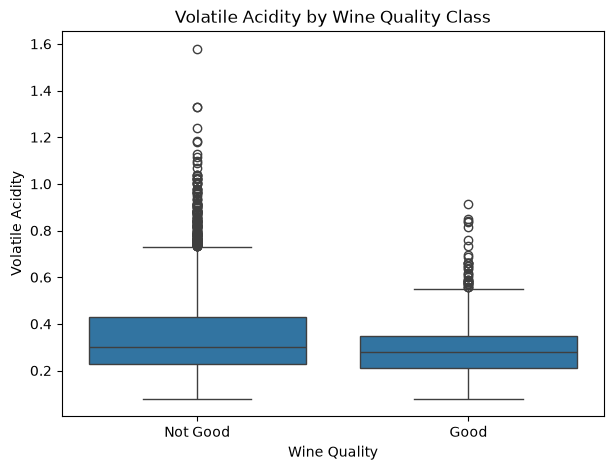

In [16]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=data, x="is_good", y="volatile_acidity")

plt.title("Volatile Acidity by Wine Quality Class")
plt.xlabel("Wine Quality")
plt.ylabel("Volatile Acidity")
plt.xticks([0, 1], ["Not Good", "Good"])

plt.show()

### Observation

Good wines generally have lower volatile acidity than Not Good wines. The Not Good group also has more high-value outliers.

## Sulphates by Wine Quality Class

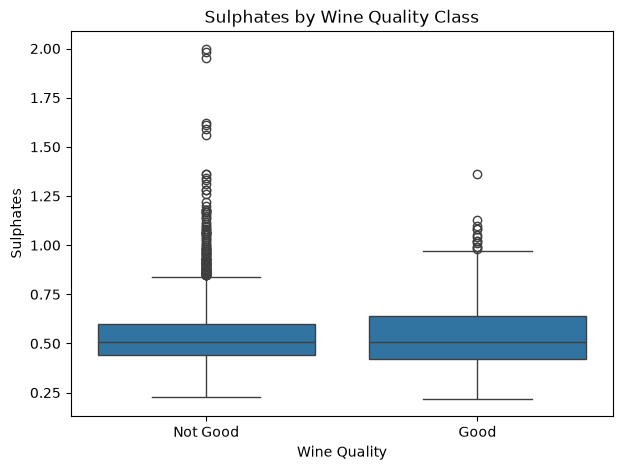

In [17]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=data, x="is_good", y="sulphates")

plt.title("Sulphates by Wine Quality Class")
plt.xlabel("Wine Quality")
plt.ylabel("Sulphates")
plt.xticks([0, 1], ["Not Good", "Good"])

plt.show()

### Observation

The sulphate distributions are similar for both groups. The Good group has a slightly higher median, but the two groups have substantial overlap.

## Correlation Analysis

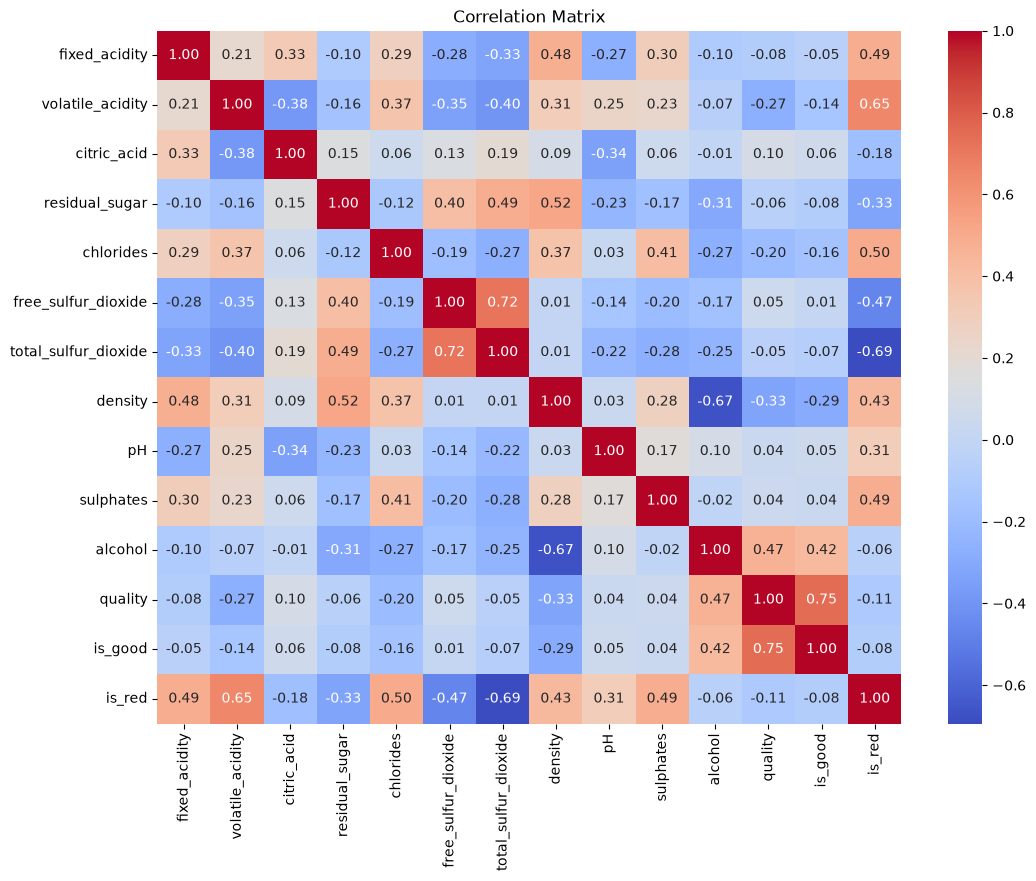

In [18]:
correlation = data.corr(numeric_only=True)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [19]:
correlation["quality"].sort_values(ascending=False)

quality                 1.000000
is_good                 0.748442
alcohol                 0.469422
citric_acid             0.097954
free_sulfur_dioxide     0.054002
sulphates               0.041884
pH                      0.039733
total_sulfur_dioxide   -0.050296
residual_sugar         -0.056830
fixed_acidity          -0.080092
is_red                 -0.114809
chlorides              -0.202137
volatile_acidity       -0.265205
density                -0.326434
Name: quality, dtype: float64

### Observation

Alcohol has the strongest positive correlation with wine quality among the chemical features. Volatile acidity, density, and chlorides have negative correlations with quality. Most other variables have weak correlations with quality. These correlations show associations, but they do not imply causation.

### Relationships Between Predictors

Free sulfur dioxide and total sulfur dioxide have a strong positive correlation. Density and alcohol also have a relatively strong negative correlation. These relationships may be important to consider when building the classification models.

## Correlation with the Target (`is_good`)

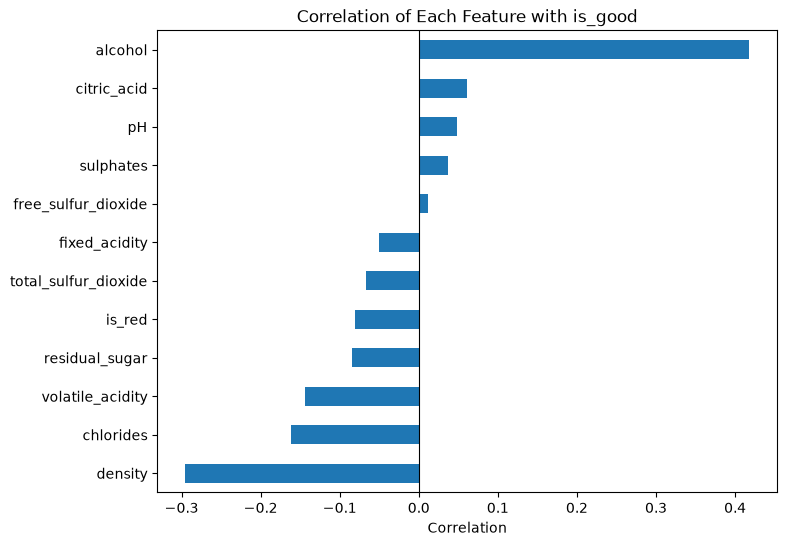

In [20]:
target_correlation = (
    correlation["is_good"]
    .drop(["is_good", "quality"])
    .sort_values()
)

plt.figure(figsize=(8, 6))

target_correlation.plot(kind="barh")

plt.title("Correlation of Each Feature with is_good")
plt.xlabel("Correlation")
plt.axvline(0, color="black", linewidth=0.8)

plt.show()

In [21]:
target_correlation.sort_values(ascending=False)

alcohol                 0.417743
citric_acid             0.060672
pH                      0.048330
sulphates               0.036771
free_sulfur_dioxide     0.011325
fixed_acidity          -0.049841
total_sulfur_dioxide   -0.067307
is_red                 -0.081083
residual_sugar         -0.084868
volatile_acidity       -0.144361
chlorides              -0.161027
density                -0.294971
Name: is_good, dtype: float64

### Observation

`quality` is left out because `is_good` is calculated directly from it. Alcohol has by far the strongest relationship with being a good wine (r = 0.42). Density (r = -0.30), chlorides (r = -0.16), and volatile acidity (r = -0.14) have the strongest negative relationships. All other features have correlations close to zero (|r| < 0.09), so on their own they say little about whether a wine is good, although they may still help in combination with other features.

Two pairs of predictors are strongly correlated with each other: free and total sulfur dioxide (r = 0.72), and density and alcohol (r = -0.67). Density is also related to residual sugar (r = 0.52). This multicollinearity can make logistic regression coefficients unstable and harder to interpret, so we should keep it in mind when choosing and explaining models.

## Alcohol and Wine Quality

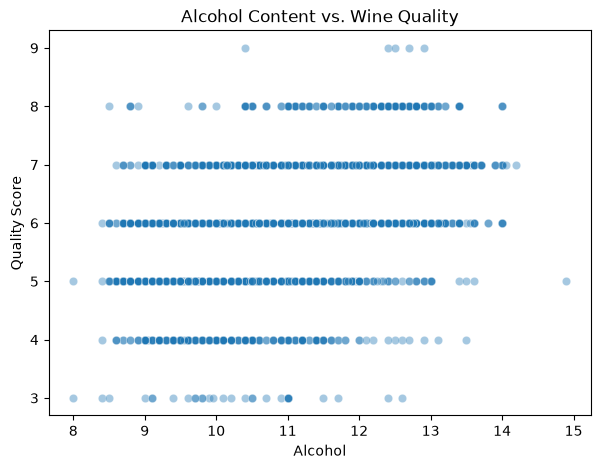

In [22]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=data, x="alcohol", y="quality", alpha=0.4)

plt.title("Alcohol Content vs. Wine Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality Score")

plt.show()

### Observation

The scatterplot shows a general positive relationship between alcohol content and wine quality. Higher quality scores tend to occur at higher alcohol levels, although there is substantial variation.

## Volatile Acidity and Wine Quality


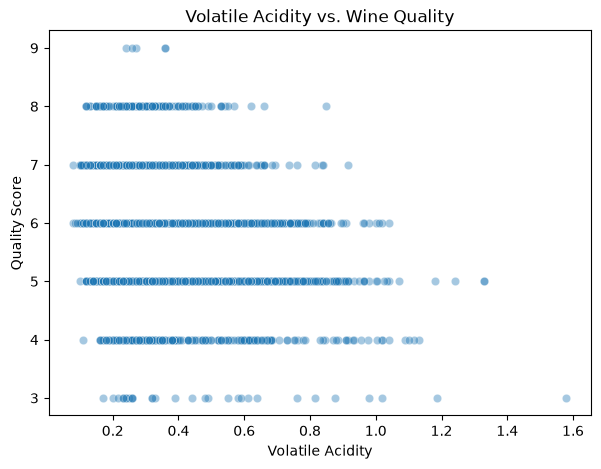

In [23]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=data, x="volatile_acidity", y="quality", alpha=0.4)

plt.title("Volatile Acidity vs. Wine Quality")
plt.xlabel("Volatile Acidity")
plt.ylabel("Quality Score")

plt.show()

### Observation

The scatterplot shows a general negative relationship between volatile acidity and wine quality. Higher quality scores tend to occur at lower levels of volatile acidity, although there is still substantial variation.

## Red vs. White Wine Quality

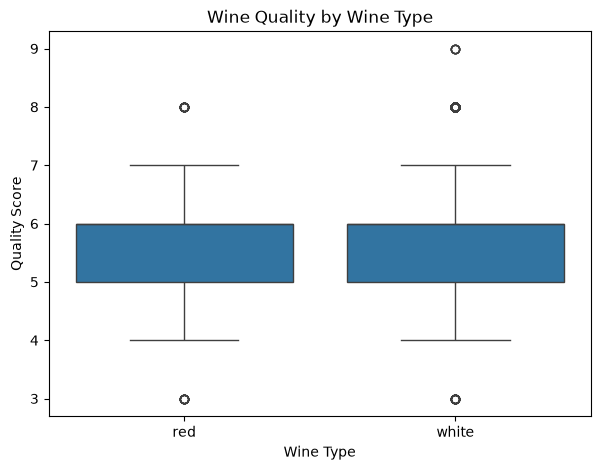

In [24]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=data, x="type", y="quality")

plt.title("Wine Quality by Wine Type")
plt.xlabel("Wine Type")
plt.ylabel("Quality Score")

plt.show()

In [25]:
data.groupby("type")["quality"].mean()

type
red      5.623252
white    5.854835
Name: quality, dtype: float64

### Observation

The quality distributions of red and white wines are fairly similar. White wines have a slightly higher average quality score (5.85) compared with red wines (5.62).

## Red vs. White Chemical Properties

In [26]:
type_medians = data.groupby("type")[features].median().T
type_medians["red_to_white_ratio"] = type_medians["red"] / type_medians["white"]

type_medians.round(3)

type,red,white,red_to_white_ratio
fixed_acidity,7.900,6.800,1.162
volatile_acidity,0.520,0.260,2.000
citric_acid,0.260,0.320,0.812
residual_sugar,2.200,4.700,0.468
chlorides,0.079,0.042,1.881
free_sulfur_dioxide,14.000,33.000,0.424
total_sulfur_dioxide,38.000,133.000,0.286
density,0.997,0.994,1.003
pH,3.310,3.180,1.041
sulphates,0.620,0.480,1.292


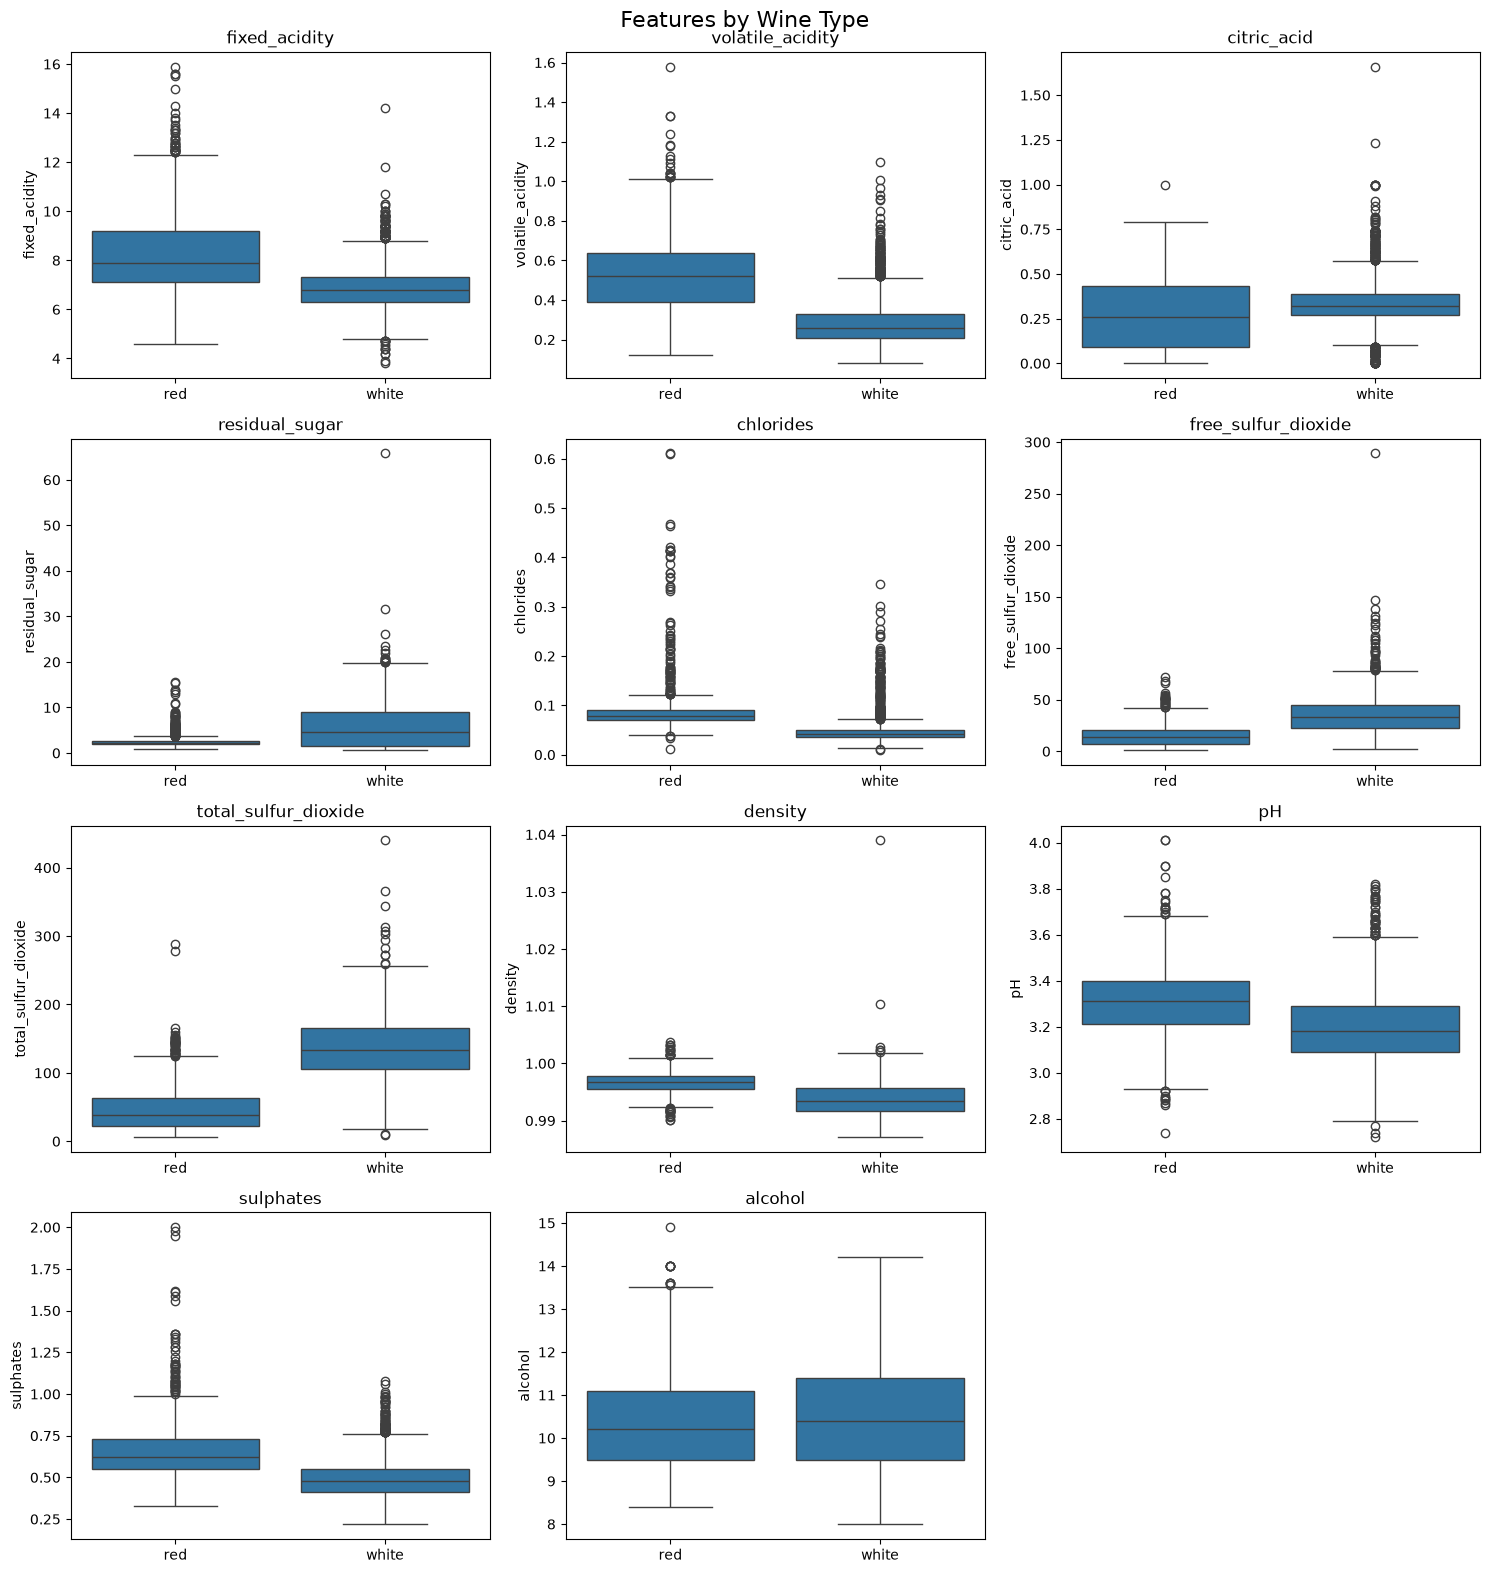

In [27]:
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=data, x="type", y=feature, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel("")

axes[-1].set_visible(False)

plt.suptitle("Features by Wine Type", fontsize=16)
plt.tight_layout()
plt.show()

### Observation

Red and white wines have very different chemistry. The biggest differences are in sulfur dioxide and sugar: white wines have a median total sulfur dioxide of 133 mg/L compared with 38 mg/L for red, more than twice the free sulfur dioxide (33 vs. 14 mg/L), and more than twice the residual sugar (4.7 vs. 2.2 g/L). Red wines have about twice the volatile acidity (0.52 vs. 0.26 g/L) and chlorides (0.079 vs. 0.042 g/L), and higher sulphates and fixed acidity. Alcohol, density, and pH are similar for both types.

This explains many of the outliers found during cleaning, since a value that is normal for one wine type can look extreme in the combined data. Because wine type affects so many features, `is_red` should be kept as a model input so the model can account for these differences.

In [28]:
data.groupby("is_good").mean(numeric_only=True).T

is_good,0,1
fixed_acidity,7.246996,7.079237
volatile_acidity,0.355879,0.293930
citric_acid,0.314175,0.336947
residual_sugar,5.233229,4.259118
chlorides,0.059561,0.044421
free_sulfur_dioxide,29.939109,30.453419
total_sulfur_dioxide,115.957550,106.211100
density,0.994958,0.992727
pH,3.220914,3.240684
sulphates,0.530694,0.544737


 ### Observation

The Good and Not Good groups show differences in several features. Good wines have higher average alcohol and lower average volatile acidity and density. These differences suggest that these features may be useful for predicting wine quality.

## EDA Summary

The exploratory analysis showed that most wines have quality scores of 5 or 6, with fewer wines receiving higher scores. Only about 19% of wines are Good, so the target is imbalanced and accuracy alone will not be a good metric for the models.

Most features are right-skewed, especially chlorides, sulphates, and residual sugar, so feature scaling should be part of the modeling step. Red and white wines differ a lot in sulfur dioxide, sugar, volatile acidity, and chlorides, so wine type (`is_red`) should be kept as an input.

Alcohol is the strongest single predictor of a Good wine (r = 0.42 with `is_good`), followed by density, chlorides, and volatile acidity, which are negatively related. Most other features have weak correlations on their own. Free and total sulfur dioxide, and density and alcohol, are strongly correlated with each other, which matters for models like logistic regression. Red and white wines had fairly similar quality distributions.